In [297]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
# Load the dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [298]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()

In [299]:
#Step 1: Create a DataFrame from the dataset
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target

In [300]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [301]:
#Step 2: Check for duplicates
df.duplicated().sum()

0

When im checking the duplicates I got - " 0 " . The dataset is clcean , now rows need to be reoved for this reason.

In [302]:
#Step3 : Handle the 500k Cap
rows = df[df['Price'] >= 4.99]
print(f"Total rows with Price >= $500K: {len(rows)}")

df_clean = df[df['Price'] < 4.99]
print(f"before: {df.shape}")
print(f"after: {df_clean.shape}")


Total rows with Price >= $500K: 994
before: (20640, 9)
after: (19646, 9)


Problem : 
* The dataset as artifical cap - any house worth more than 500k is was recorded as exacly 500k
* so they are not real data 

why moed hurts :
* If dont remove fake /incomplete data my model will learn from that data . And it will always unprediact expensive houses 

My Decision :
* we remove them so model only learns from accurate and trusty dataa
* At the end we lose 965 rows but matching 19,000 rows are cleaner and perfect .

In [303]:
# Step 4: Remove AveRooms and AveOccup outliers

df_clean = df_clean[df_clean['AveRooms'] < 50]
df_clean = df_clean[df_clean['AveOccup'] < 20]
print(f"After {df_clean.shape}")

After (19629, 9)


After removing $500k capped rows and outliers in AveRooms and Aveoccup, dataset reduced from 20,640 to 19,629 rows. Removd 1,011 rows (about 5%)".

In [304]:
#step 5 : Pratice missing values

print(df_clean.isnull().sum())

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64


* This is pratice only - there are no missing values in this dataset 
* if there were , we weould fill them like this 
df_clean = df_clean.fillna(df_clean.median())


# Day 6 - Feature Engineering
* Goal - To create new features from existing ones that help the model understand the data better.

In [305]:
#Step1- Create new column from existing data
df_clean['RoomsPerHousehold'] = df_clean['AveRooms'] / df_clean['AveOccup']


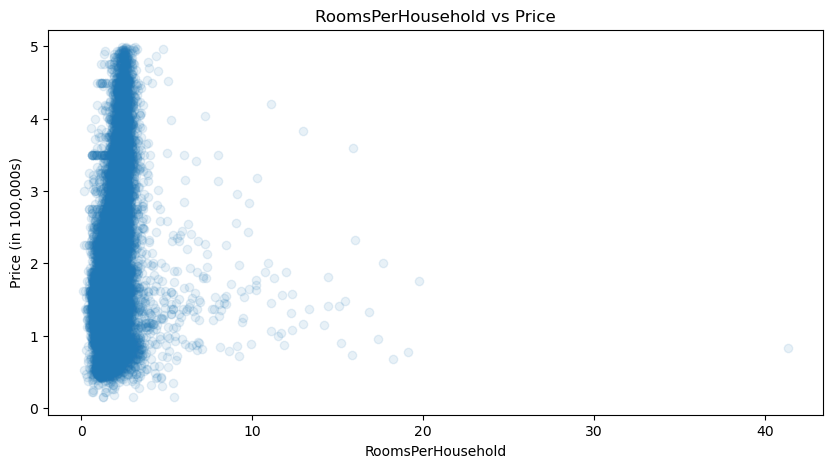

In [306]:
plt.figure(figsize=(10, 5))
plt.scatter(df_clean['RoomsPerHousehold'], df_clean['Price'], alpha=0.1)
plt.xlabel('RoomsPerHousehold')
plt.ylabel('Price (in 100,000s)')
plt.title('RoomsPerHousehold vs Price')
plt.show()

In [307]:
#Step1- Create new column from existing data
df_clean['BedroomPerRoom'] = df_clean['AveBedrms'] / df_clean['AveRooms']

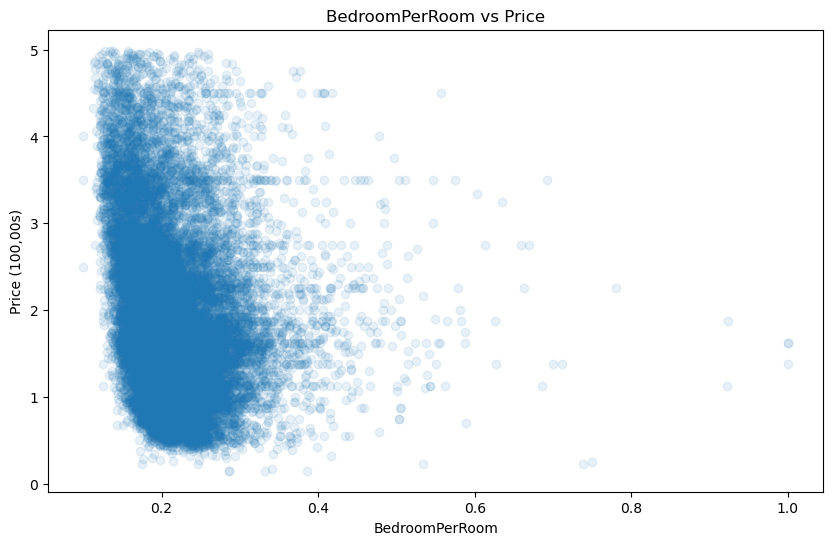

In [308]:
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['BedroomPerRoom'], df_clean['Price'], alpha=0.1)
plt.xlabel('BedroomPerRoom')
plt.ylabel('Price (100,00s)')
plt.title('BedroomPerRoom vs Price')
plt.show()

In [309]:
df_clean['PopulationPerHousehold'] = df_clean['Population'] / df_clean['AveOccup']


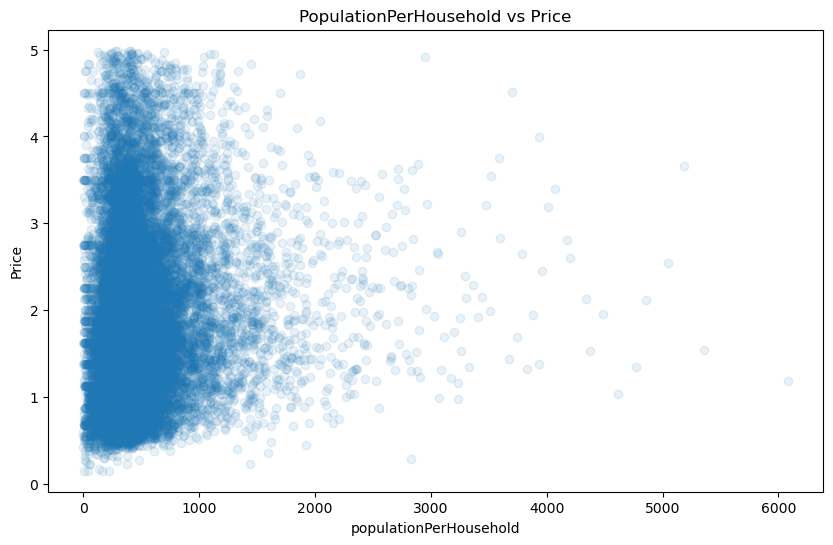

In [310]:
plt.figure(figsize=(10,6))
plt.scatter(df_clean['PopulationPerHousehold'], df_clean['Price'], alpha=0.1)
plt.xlabel('populationPerHousehold')
plt.ylabel('Price')
plt.title('PopulationPerHousehold vs Price')
plt.show()

In [311]:
df_clean['Distance_from_coast'] = abs(df_clean['Longitude'] -(-120))

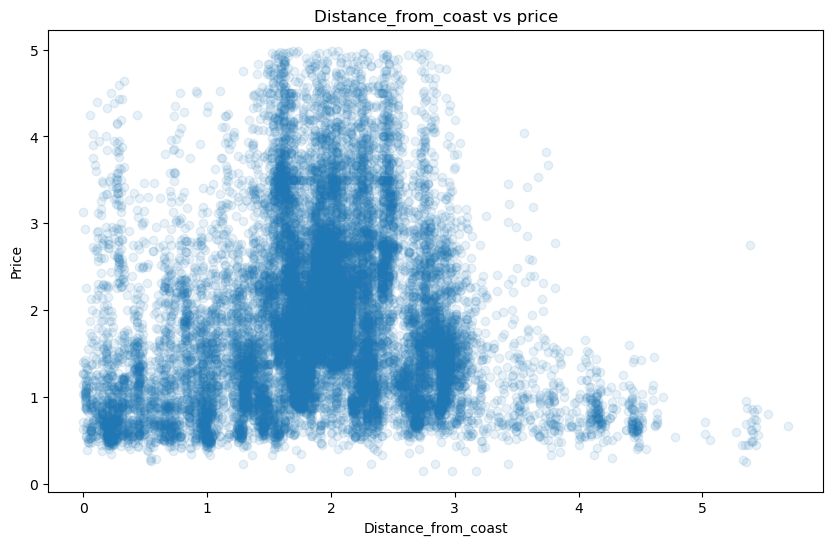

In [312]:
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['Distance_from_coast'], df_clean['Price'], alpha=0.1)
plt.xlabel('Distance_from_coast')
plt.ylabel('Price')
plt.title('Distance_from_coast vs price')
plt.show()

## Day 6 - Markdown

### New Features Created:
- RoomPerhoushold = AveRooms / AveOccup
- BedroomPErRoom = AveBedrms / AveRooms
- PopulationPerHousld = Population / AveOccup
- Distance_from_coast = how far each district from logitude -120

### What I Found From plots:
- RoomsPerHousehold - weak pattern, no Clear direction
- BedroomPerRoom - Strongest pattern, clear Downward trend (mored bedroom ratio = chaper house)
- PopulationPerHousehold = Population / AveOcup
- Diatance_from_coast = how far each district is from longititude

Key takeaway :
- BedroomPerRoom is the most useful new features
- Feature engineering helps the model find patterns it couldn't see before


In [313]:
print(df_clean.columns)
print(df_clean.shape)


Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Price', 'RoomsPerHousehold', 'BedroomPerRoom',
       'PopulationPerHousehold', 'Distance_from_coast'],
      dtype='object')
(19629, 13)


## Day 7 - Scaling & Saving the data!


In [314]:
#Step1: Split X and Y
X = df_clean[["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population", "AveOccup", "Latitude", "Longitude", "RoomsPerHousehold", "BedroomPerRoom", "PopulationPerHousehold", "Distance_from_coast"]]
y = df_clean[["Price"]]

In [315]:
#split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [316]:
print(f"X_train; {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train; (15703, 12)
X_test: (3926, 12)
y_train: (15703, 1)
y_test: (3926, 1)


In [317]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

print("Scaling Done!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")


Scaling Done!
X_train_scaled shape: (15703, 12)


In [318]:
joblib.dump(X_train_scaled, '../data/X_train.pkl')
joblib.dump(X_test_scaled, '../data/X_test.pkl')
joblib.dump(y_train, '../data/y_train.pkl')
joblib.dump(y_test, '../data/y_test.pkl')
joblib.dump(scaler, '../data/scaler.pkl')

print("ALl files saved!")

ALl files saved!


In [319]:
print(os.listdir('../data'))

['scaler.pkl', 'y_train.pkl', 'X_test.pkl', 'y_test.pkl', 'X_train.pkl', '.gitignore']


## Day7 - Summary
- Split data into 80% train(15,703 rows) and 20% test (3,926 rows).
- Applied Saler to X features only - fit the train , transform both.
- Saved all preapred data and scaler to data/ folder using joblib.
- Data is now ready for Modelling.
